In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import shap

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded ✓')

/Users/rnorel/.pyenv/versions/3.11.14/envs/beats-and-focus/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded ✓


In [3]:
df = pd.read_csv('../data/raw/tracks.csv')
df_clean = df[df['tempo'] > 0].copy()

# Binary outcome: popularity >= 50
THRESHOLD = 50
df_clean['target'] = (df_clean['popularity'] >= THRESHOLD).astype(int)

# Features
features = ['tempo', 'energy', 'valence', 'danceability',
            'acousticness', 'instrumentalness', 'speechiness', 'loudness']

X = df_clean[features]
y = df_clean['target']

print(f'Shape: {X.shape}')
print(f'Target distribution:')
print(y.value_counts())
print(f'Success rate: {y.mean()*100:.1f}%')

Shape: (2016, 8)
Target distribution:
target
0    1660
1     356
Name: count, dtype: int64
Success rate: 17.7%


## Predictive Modeling

**Goal:** predict which tracks reach mainstream popularity (popularity ≥ 50).

**Features:** tempo (BPM), energy, valence, danceability, acousticness, 
instrumentalness, speechiness, loudness.

**Target:** popularity ≥ 50 (17.7% success rate — imbalanced dataset)

**Key question:** where does `tempo` rank among all features in predicting popularity?
If BPM were the driver of engagement, we would expect it to rank highly in SHAP importance.

**Models:** Logistic Regression, Random Forest, Gradient Boosting.
All evaluated with AUC-ROC via 5-fold cross-validation.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

print('AUC-ROC (5-fold cross-validation):')
for name, model in models.items():
    X_cv = X_train_scaled if name == 'Logistic Regression' else X_train
    scores = cross_val_score(model, X_cv, y_train, cv=5, scoring='roc_auc')
    print(f'  {name}: {scores.mean():.3f} ± {scores.std():.3f}')

AUC-ROC (5-fold cross-validation):
  Logistic Regression: 0.691 ± 0.027
  Random Forest: 0.732 ± 0.017
  Gradient Boosting: 0.727 ± 0.016


## Model Performance

| Model | AUC-ROC | Std |
|-------|---------|-----|
| Logistic Regression | 0.691 | ±0.027 |
| Random Forest | 0.732 | ±0.017 |
| Gradient Boosting | 0.727 | ±0.016 |

All three models perform similarly — AUC ~0.69-0.73.
This suggests the relationship between audio features and popularity is 
largely linear, with modest non-linear gains from tree-based models.

A random classifier would score 0.50 — our models are meaningfully better than chance,
but far from perfect. Popularity is inherently noisy and driven by factors
beyond audio features (artist fame, marketing, playlist placement, etc.).

We proceed with **Random Forest** for SHAP analysis — highest AUC and stable variance.

In [5]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Test set AUC
y_pred_proba = rf.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_pred_proba)
print(f'Random Forest — Test AUC: {test_auc:.3f}')

Random Forest — Test AUC: 0.687


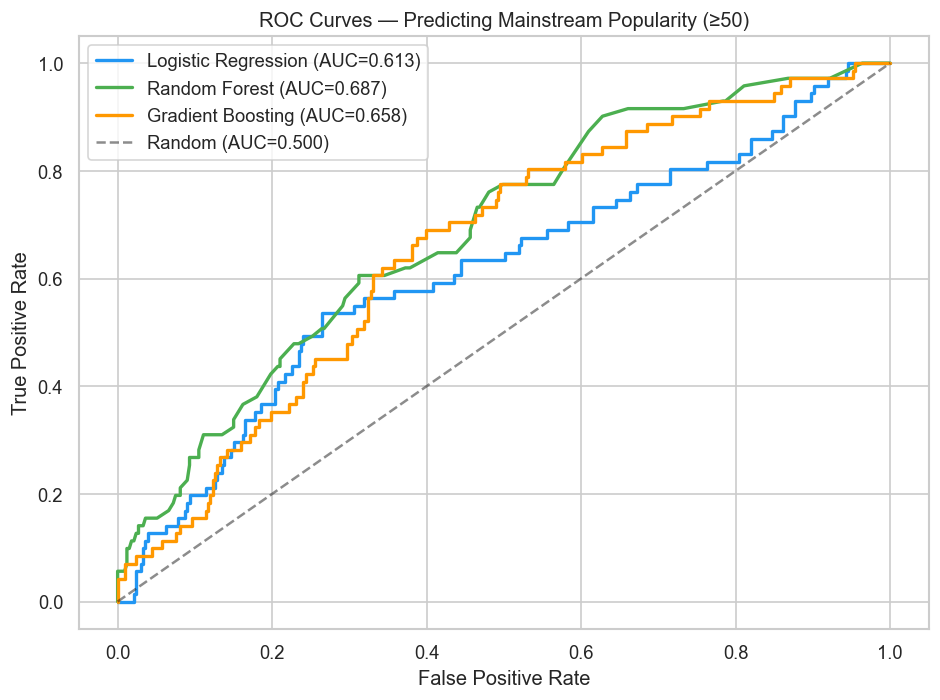

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

model_colors = {
    'Logistic Regression': '#2196F3',
    'Random Forest': '#4CAF50',
    'Gradient Boosting': '#FF9800'
}

for name, model in models.items():
    X_fit = X_train_scaled if name == 'Logistic Regression' else X_train
    X_eval = X_test_scaled if name == 'Logistic Regression' else X_test
    model.fit(X_fit, y_train)
    y_proba = model.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=model_colors[name], linewidth=2, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Predicting Mainstream Popularity (≥50)')
ax.legend()

plt.tight_layout()
plt.savefig('../figures/full_07_roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

In [7]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# For binary classification, shap_values is a list — take class 1
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

print('SHAP values computed ✓')
print(f'Shape: {sv.shape}')

SHAP values computed ✓
Shape: (404, 8, 2)


In [8]:
sv = shap_values[:, :, 1]
print(f'Shape after selecting class 1: {sv.shape}')

Shape after selecting class 1: (404, 8)


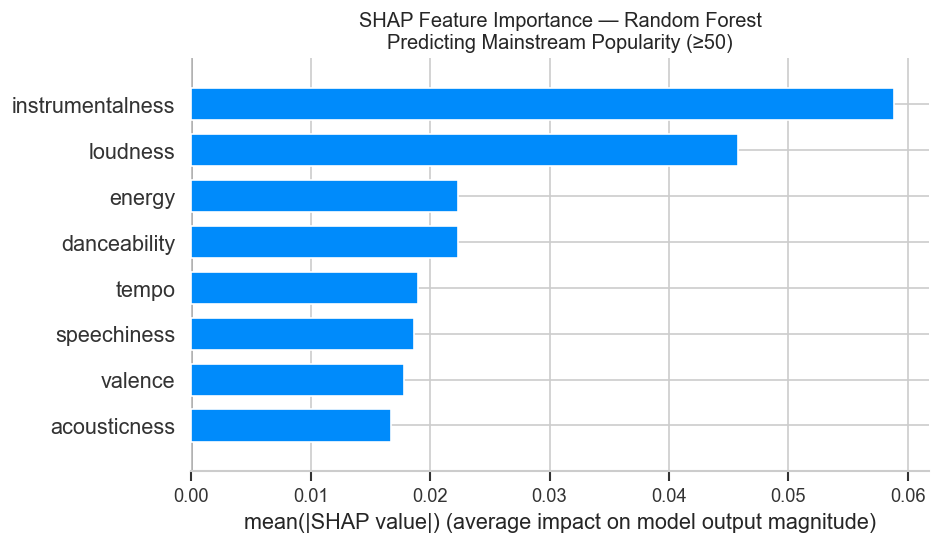

In [9]:
shap.summary_plot(sv, X_test, plot_type='bar', 
                  feature_names=features,
                  show=False)
plt.title('SHAP Feature Importance — Random Forest\nPredicting Mainstream Popularity (≥50)')
plt.tight_layout()
plt.savefig('../figures/full_08_shap_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## SHAP Feature Importance

**`tempo` ranks 5th out of 8 features** — in the middle of the pack.

Top predictors of mainstream popularity:
1. **instrumentalness** — by far the most important feature
2. **loudness** — second most important
3. **energy** — third
4. **danceability** — fourth
5. **tempo** — fifth

**This is the central finding of the project:**
After controlling for all other audio features, BPM has modest predictive power —
less than instrumentalness, loudness, energy, and danceability.

Focus tracks are highly instrumental and low loudness/energy — those features,
not tempo, explain why they differ from context tracks in popularity.
This is the confounding that observational data cannot resolve:
groups differ in BPM *and* in many other dimensions simultaneously.

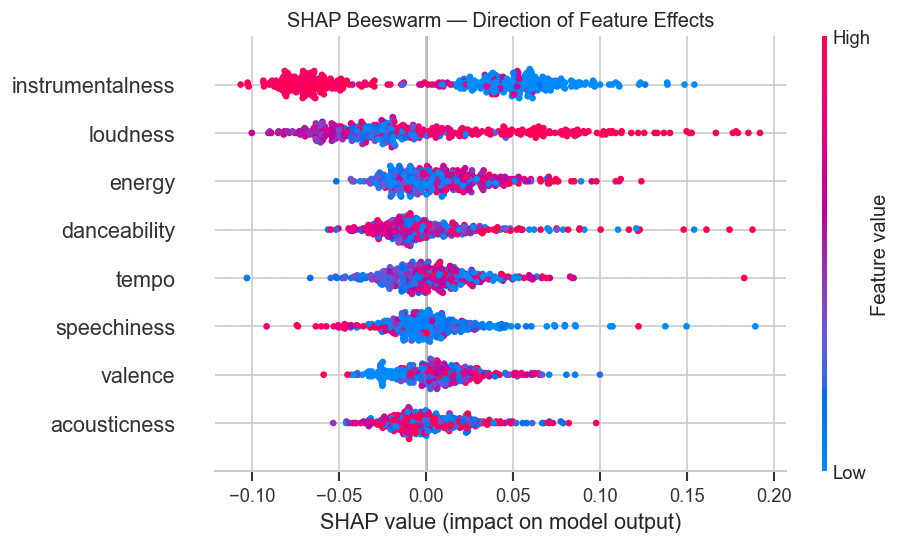

In [10]:
shap.summary_plot(sv, X_test, feature_names=features, show=False)
plt.title('SHAP Beeswarm — Direction of Feature Effects')
plt.tight_layout()
plt.savefig('../figures/full_09_shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()

## SHAP Beeswarm — Direction of Effects

- **instrumentalness:** high values (red) → negative SHAP → **more instrumental = less popular**
- **loudness:** high values (red) → positive SHAP → **louder = more popular**
- **energy:** high values (red) → positive SHAP → **more energetic = more popular**
- **tempo:** mixed — no clear directional pattern

**The confounding explained:**
Focus tracks have high instrumentalness (0.588) and low energy (0.264).
These two features alone explain why focus tracks score lower on popularity —
not their BPM. The groups were never comparable on these dimensions.

## SHAP Beeswarm — Direction of Effects

- **instrumentalness:** high values (red) → negative SHAP → **more instrumental = less popular**
- **loudness:** high values (red) → positive SHAP → **louder = more popular**
- **energy:** high values (red) → positive SHAP → **more energetic = more popular**
- **tempo:** mixed — no clear directional pattern

**The confounding explained:**
Focus tracks have high instrumentalness (0.588) and low energy (0.264).
These two features alone explain why focus tracks score lower on popularity —
not their BPM. The groups were never comparable on these dimensions.

## Notebook 4 — Summary

| Feature | SHAP Rank | Direction |
|---------|-----------|-----------|
| instrumentalness | 1st | High → less popular |
| loudness | 2nd | High → more popular |
| energy | 3rd | High → more popular |
| danceability | 4th | High → more popular |
| **tempo** | **5th** | No clear direction |
| speechiness | 6th | Mixed |
| valence | 7th | Mixed |
| acousticness | 8th | Mixed |

**Central finding:** `tempo` ranks 5th out of 8 features.
After controlling for instrumentalness, loudness, energy and danceability —
BPM has modest and directionally unclear predictive power over popularity.

The popularity gap between Focus and Context tracks is explained by
instrumentalness and energy — not tempo. This is the confound that
observational data cannot disentangle: you cannot isolate the effect of BPM
when focus music is simultaneously more instrumental, quieter, and lower energy.

> Correlation ≠ causation — whether you're running clinical trials
> or building a focus playlist.